# Unsupervised Learning: K-Means & Hierarchical Clustering


## 1. What is Unsupervised Learning?

Unsupervised learning is a machine learning paradigm where the algorithm learns patterns from **unlabeled data**.

There is **no target variable** ($y$). The algorithm tries to discover **hidden structure** inside the data ($X$).

Instead of predicting outcomes, it answers questions like:
* Are there **groups** in the data?
* Are some observations **similar**?
* Are there **outliers**?
* Can the data be **compressed** into fewer dimensions?

### Setting up the Environment
Let's import the necessary libraries we will use throughout this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler

# Scipy for dendrograms
import scipy.cluster.hierarchy as sch

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

## 2. K-Means Clustering

K-Means is a **centroid-based clustering algorithm** that partitions data into **K clusters**.
Each cluster has a **center called centroid**.

The algorithm minimizes the distance between points and their respective cluster centroid: $\sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2$

### Intuition of K-Means (Step-by-Step with Code)

Let's build a simple synthetic dataset to visualize how K-Means defines clusters.

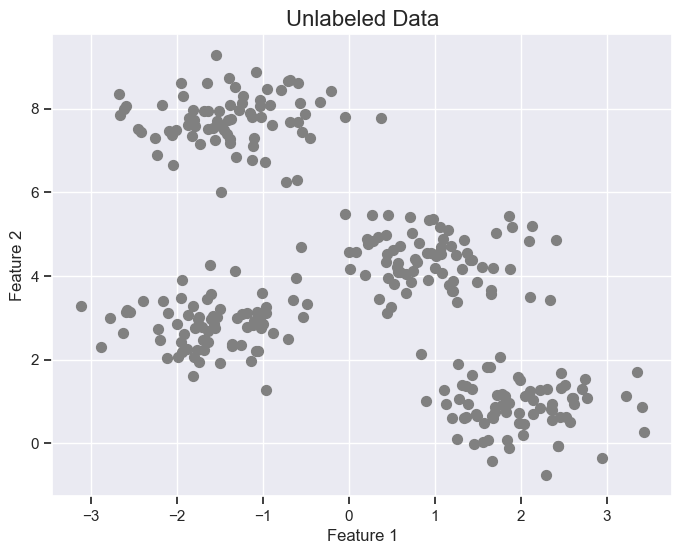

In [2]:
# Create synthetic data with 4 distinct clusters
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, color='gray')
plt.title("Unlabeled Data", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Now, let's apply the **K-Means algorithm** using Scikit-Learn.

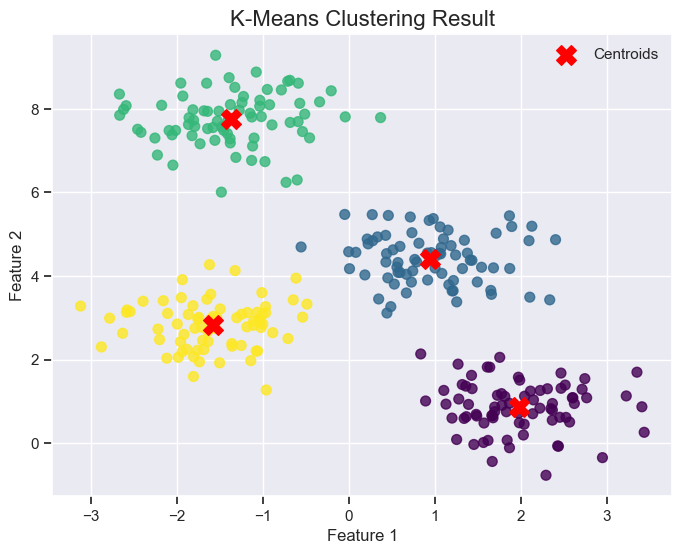

In [3]:
# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)

# Fit the algorithm to the data and predict the cluster assignments
y_kmeans = kmeans.fit_predict(X)

# Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.8)

# Plot the centroids
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering Result", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### How K-Means Works:
1. **Initialize Centroids:** Randomly place $K$ centroids in the data space.
2. **Assign Points:** Assign each data point to the nearest centroid.
3. **Update Centroids:** Recompute the centroid as the mean of all points assigned to it.
4. **Repeat:** Repeat steps 2 and 3 until the centroids stop moving (convergence).

---

## 3. Choosing the Best $K$: The Elbow Method

One of the main limitations of K-Means is that we must specify the number of clusters ($K$) beforehand.

To find the optimal $K$, we use the **Elbow Method**. We evaluate models for different values of $K$ and plot the **WCSS (Within-Cluster Sum of Squares)**, also known as **Inertia**.

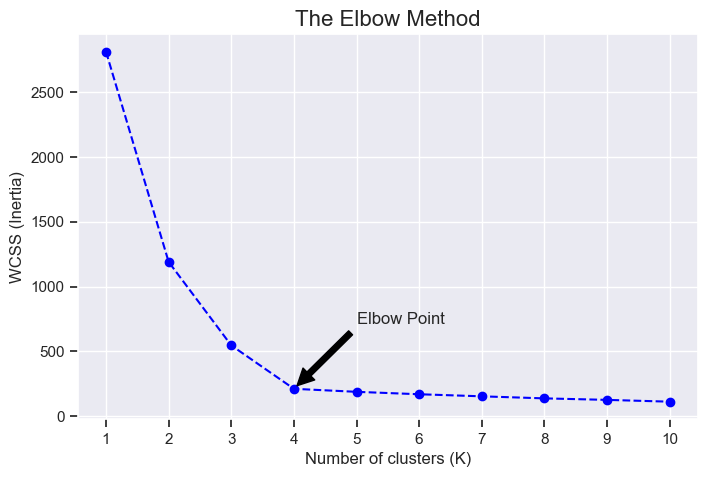

In [4]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans_test.fit(X)
    wcss.append(kmeans_test.inertia_) # Inertia is the WCSS

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method', fontsize=16)
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)

# Annotate the 'elbow'
plt.annotate('Elbow Point', xy=(4, wcss[3]), xytext=(5, wcss[3] + 500),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

**Observation:** The WCSS drops rapidly as we increase $K$. However, after $K=4$, the rate of decrease slows down significantly, forming an 'elbow'. Thus, **$K=4$** is the optimal number of clusters for this dataset.

---

## 4. Evaluating Clusters: Silhouette Score

While WCSS measures cohesion (how tight a cluster is), the **Silhouette Score** measures both cohesion AND separation (how far apart distinct clusters are).

Range: **$-1$ to $+1$**.
* **+1:** Excellent clustering.
* **0:** Borderline (overlapping clusters).
* **-1:** Terrible clustering (points might be in the wrong cluster).

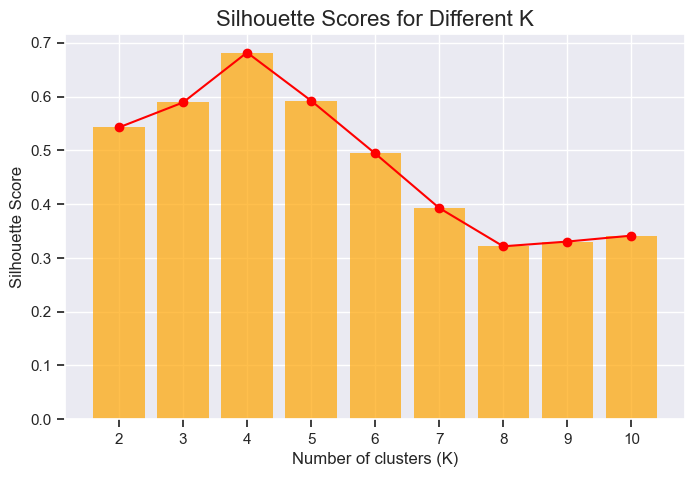

The highest Silhouette Score is 0.682 at K = 4


In [5]:
silhouette_scores = []
K_range_sil = range(2, 11) # Silhouette score requires at least 2 clusters

for k in K_range_sil:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_test.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.bar(K_range_sil, silhouette_scores, color='orange', alpha=0.7)
plt.plot(K_range_sil, silhouette_scores, marker='o', color='red')
plt.title('Silhouette Scores for Different K', fontsize=16)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.show()

print(f"The highest Silhouette Score is {max(silhouette_scores):.3f} at K = {K_range_sil[np.argmax(silhouette_scores)]}")

---

## 5. Limitations of K-Means

K-Means is powerful but has flaws, particularly when clusters are not spherical.

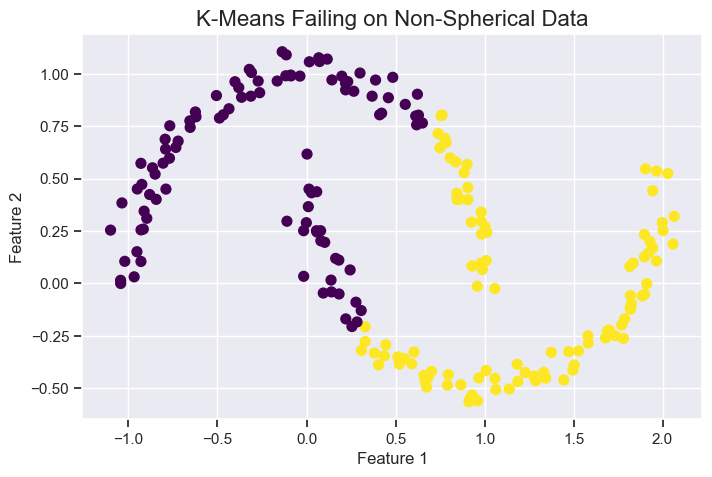

In [6]:
# Create a dataset with non-spherical (crescent moon) clusters
X_moon, y_moon = make_moons(n_samples=200, noise=0.05, random_state=42)

# Try K-Means
kmeans_moon = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels_moon = kmeans_moon.fit_predict(X_moon)

plt.figure(figsize=(8, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon, cmap='viridis', s=50)
plt.title("K-Means Failing on Non-Spherical Data", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Observation:** K-Means forces a linear boundary and fails to capture the curved structure of the moons. Other algorithms (like DBSCAN, not covered here) solve this.

---

## 6. Hierarchical Clustering

Hierarchical clustering builds a **tree of clusters** (Dendrogram). We don't need to specify $K$ at the beginning!

**Agglomerative (Bottom-Up):**
1. Start with $N$ clusters (each point is its own cluster).
2. Merge the two closest clusters.
3. Repeat until there is only 1 giant cluster.

### Visualizing the Hierarchy: The Dendrogram

A Dendrogram visually shows every merge step. Let's use it on a subset of our original data.

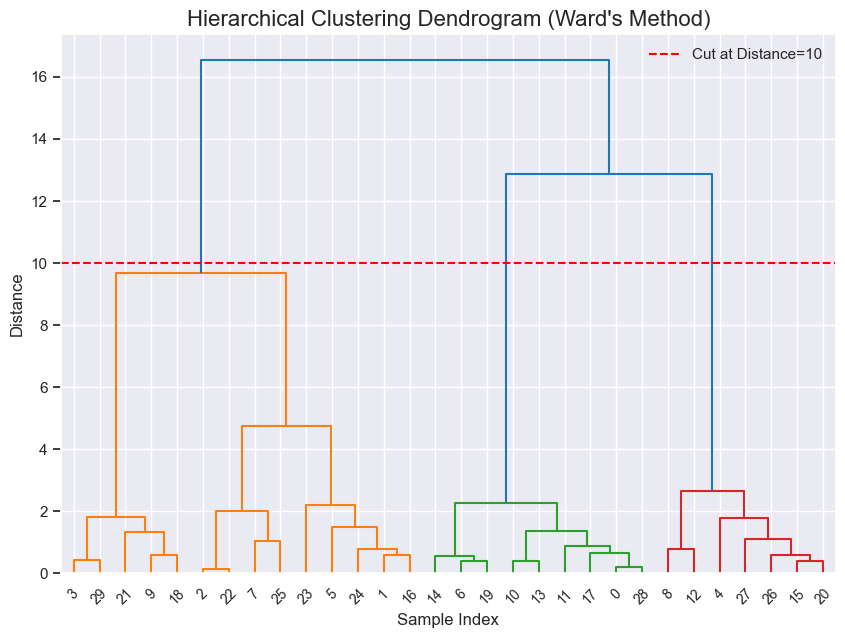

In [7]:
# Let's take a small subset of the data to make the dendrogram readable
np.random.seed(42)
indices = np.random.choice(X.shape[0], 30, replace=False)
X_subset = X[indices]

plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=16)
plt.xlabel("Sample Index")
plt.ylabel("Distance")

# Plot the dendrogram using scipy
# Ward's method minimizes the variance of the clusters being merged.
dendrogram = sch.dendrogram(sch.linkage(X_subset, method='ward'))

# Draw a horizontal line to show where we could "cut" the tree
plt.axhline(y=10, color='r', linestyle='--', label='Cut at Distance=10')
plt.legend()
plt.show()

### Applying Agglomerative Clustering

Once we determine the desired number of clusters (e.g., by looking at the dendrogram), we can apply Sklearn's model.

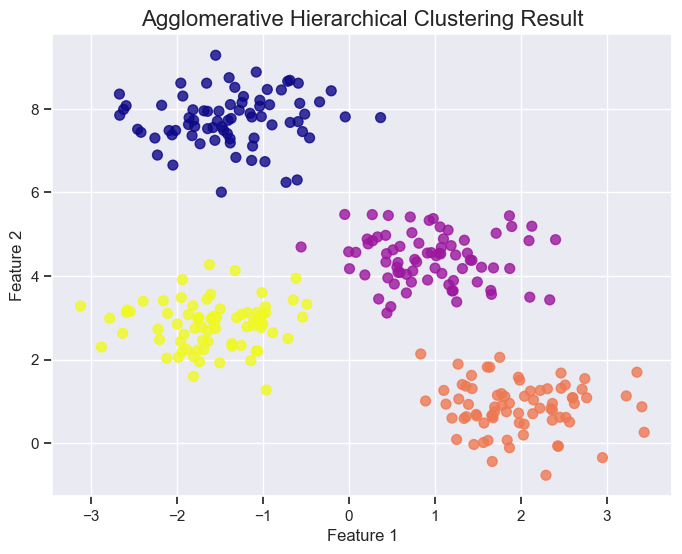

In [8]:
# Fit Agglomerative Clustering
# We set n_clusters=4 based on what we learned from the complete dataset earlier
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_hc, s=50, cmap='plasma', alpha=0.8)
plt.title("Agglomerative Hierarchical Clustering Result", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 7. Wine Dataset


Since this is unsupervised learning, we will **hide the labels** and see if K-Means can figure out the 3 wine types purely based on their chemical properties!

In [9]:
# Load Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target # The true labels (we pretend we don't know these)
component_names = wine.feature_names

# Convert to DataFrame for better viewing
df_wine = pd.DataFrame(X_wine, columns=component_names)
display(df_wine.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Why Scaling is CRITICAL for Distance-Based Algorithms

K-Means uses Euclidean distance. If one feature is measured in thousands (like Proline) and another in small decimals (like Nonflavanoid phenols), the feature with larger numbers will completely dominate the distance calculation.

**Always scale your data before using K-Means or Hierarchical Clustering!**

In [10]:
# Scale the data explicitly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

print(f"Original Proline variance: {X_wine[:, 12].var():.2f}")
print(f"Scaled Proline variance: {X_scaled[:, 12].var():.2f}")

Original Proline variance: 98609.60
Scaled Proline variance: 1.00


### Applying K-Means to the Scaled Wine Data

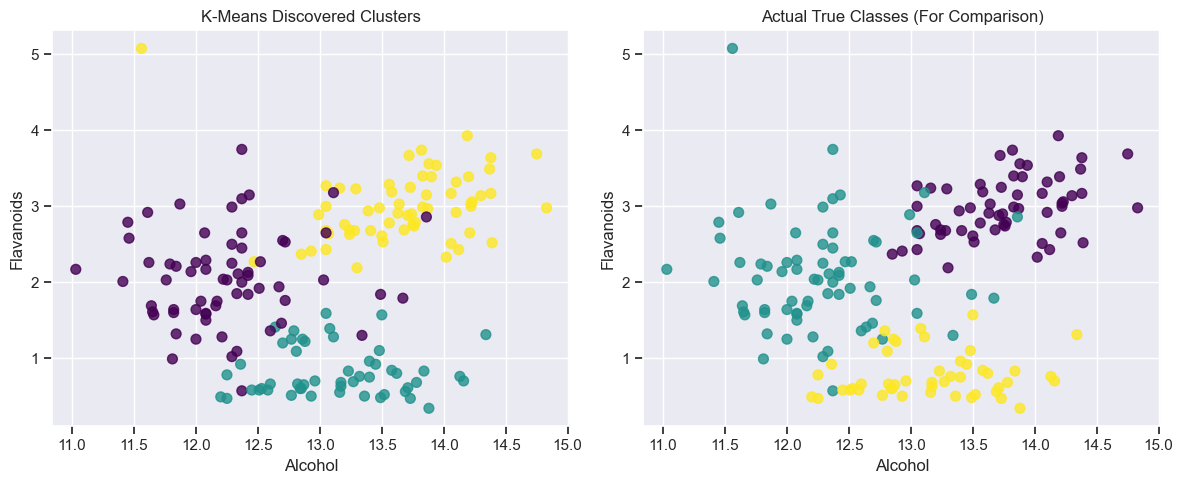

Silhouette Score on the Wine dataset: 0.285


In [11]:
# We know there are 3 wine cultivars
kmeans_wine = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_wine.fit_predict(X_scaled)

# Since we have 13 features, we can't plot them all at once.
# Let's pick two features to visualize the clusters: 'alcohol' (idx 0) and 'flavanoids' (idx 6)
plt.figure(figsize=(12, 5))

# Plot 1: Unsupervised K-Means Clusters
plt.subplot(1, 2, 1)
plt.scatter(X_wine[:, 0], X_wine[:, 6], c=cluster_labels, cmap='viridis', s=50, alpha=0.8)
plt.title("K-Means Discovered Clusters")
plt.xlabel("Alcohol")
plt.ylabel("Flavanoids")

# Plot 2: Actual True Classes
plt.subplot(1, 2, 2)
plt.scatter(X_wine[:, 0], X_wine[:, 6], c=y_wine, cmap='viridis', s=50, alpha=0.8)
plt.title("Actual True Classes (For Comparison)")
plt.xlabel("Alcohol")
plt.ylabel("Flavanoids")

plt.tight_layout()
plt.show()

# How well did it separate them? Let's check the Silhouette Score:
score_wine = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score on the Wine dataset: {score_wine:.3f}")

**Observation:** Even without knowing the labels, K-Means successfully identified 3 distinct groups of wine based purely on their chemical properties! This highlights the power of unsupervised learning for discovering hidden patterns.

---

## 8. K-Means vs Hierarchical Clustering Summary

| Feature | K-Means | Hierarchical |
| :--- | :--- | :--- |
| **Approach** | Partitioning | Tree-based |
| **Speed** | Fast ($O(N)$) | Slow ($O(N^3)$) |
| **Need $K$ beforehand?** | Yes | No |
| **Exploratory Visual** | Low | High (Dendrogram) |
| **Scalability** | Good for Large Data | Bad for Large Data |